# Sector-Aware Feature Selection Findings

This notebook showcases the feature-selection outputs at two levels:
1. **Ticker-wise**: top macro drivers for each stock
2. **Sector-wise**: how macro groups differ across sectors

The analysis reads the generated files from `data/feature_selection`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)


In [ ]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        direct = path
        nested = path / 'financial_loss_functions'

        if (direct / 'config' / 'paths.json').exists() and (direct / 'data').exists():
            return direct
        if (nested / 'config' / 'paths.json').exists() and (nested / 'data').exists():
            return nested

    raise FileNotFoundError('Could not locate financial_loss_functions project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
FEATURE_DIR = PROJECT_ROOT / 'data' / 'feature_selection'

rankings_path = FEATURE_DIR / 'ticker_macro_rankings.csv'
selected_path = FEATURE_DIR / 'ticker_selected_features.csv'
sector_map_path = FEATURE_DIR / 'sector_assignment_50.csv'

for p in [rankings_path, selected_path, sector_map_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')

rankings = pd.read_csv(rankings_path)
selected = pd.read_csv(selected_path)
sector_map = pd.read_csv(sector_map_path)

if summary_path.exists():
    display(Markdown(summary_path.read_text()))

print('Project root:', PROJECT_ROOT)
print('Feature output dir:', FEATURE_DIR)
print('rankings shape:', rankings.shape)
print('selected shape:', selected.shape)
print('sector_map shape:', sector_map.shape)


Project root: /Users/atharvavaidya/Desktop/Sem-3/DSCI/Code/exact/financial_loss_functions
Feature output dir: /Users/atharvavaidya/Desktop/Sem-3/DSCI/Code/exact/financial_loss_functions/data/feature_selection
rankings shape: (5150, 10)
selected shape: (500, 10)
sector_map shape: (50, 5)


In [3]:
display(selected.head(10))

print('Unique tickers in selected:', selected['ticker'].nunique())
print('Rows per ticker (should be top-k each):')
display(selected.groupby('ticker').size().describe())

print('Unique sectors in mapping:', sector_map['sector'].nunique())
display(sector_map['sector'].value_counts())


,ticker,macro_feature,macro_group,best_lag,max_abs_spearman_corr,sector_prior_weight,normalized_max_abs_corr,composite_score,low_corr_flag,rank
0,AKAM,PPIITM,Prices,10,0.043629,1.00,0.933068,0.953148,True,1
1,AKAM,PPICRM,Prices,10,0.036359,1.00,0.777580,0.844306,True,2
2,AKAM,MCOILWTICO,Prices,50,0.034455,1.00,0.736856,0.815799,True,3
3,AKAM,IPNMAT,Output_Income,60,0.046759,0.05,1.000000,0.715000,True,4
4,AKAM,PPICMM,Prices,10,0.026438,1.00,0.565400,0.695780,True,5
5,AKAM,CPITRNSL,Prices,60,0.024795,1.00,0.530277,0.671194,True,6
6,AKAM,DTCTHFNM,Money_Credit,50,0.042974,0.05,0.919055,0.658339,True,7
7,AKAM,CUUR0000SAD,Prices,60,0.022608,1.00,0.483510,0.638457,True,8
8,AKAM,SP500,Stock_Market,60,0.020093,1.00,0.429704,0.600793,True,9
9,AKAM,EXUSUK,Rates_FX,10,0.038974,0.05,0.833509,0.598457,True,10


Unique tickers in selected: 50
Rows per ticker (should be top-k each):


count    50.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
dtype: float64

Unique sectors in mapping: 9


sector
Health Care               9
Real Estate               8
Financials                8
Industrials               7
Utilities                 6
Consumer Discretionary    5
Consumer Staples          3
Information Technology    2
Materials                 2
Name: count, dtype: int64

## 1) Ticker-wise Findings

The table below summarizes each ticker's strongest selected signal and group profile.

In [4]:
top1 = selected[selected['rank'] == 1][['ticker', 'macro_feature', 'macro_group', 'best_lag', 'composite_score', 'max_abs_spearman_corr']]
top1 = top1.rename(columns={
    'macro_feature': 'top_macro_feature',
    'macro_group': 'top_macro_group',
    'best_lag': 'top_lag_days',
    'composite_score': 'top_composite_score',
    'max_abs_spearman_corr': 'top_abs_spearman_corr',
})

macro_mix = (
    selected.groupby(['ticker', 'macro_group'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['ticker', 'count', 'macro_group'], ascending=[True, False, True])
)

dominant_group = (
    macro_mix.drop_duplicates('ticker')[['ticker', 'macro_group', 'count']]
    .rename(columns={'macro_group': 'dominant_macro_group', 'count': 'dominant_group_count'})
)

ticker_summary = (
    top1.merge(dominant_group, on='ticker', how='left')
    .merge(sector_map[['ticker', 'sector', 'secondary_sector']], on='ticker', how='left')
    .sort_values('ticker')
    .reset_index(drop=True)
)

display(ticker_summary)


,ticker,top_macro_feature,top_macro_group,top_lag_days,top_composite_score,top_abs_spearman_corr,dominant_macro_group,dominant_group_count,sector,secondary_sector
0,AKAM,PPIITM,Prices,10,0.953148,0.043629,Prices,6,Information Technology,NaN
1,ATO,CPIAPPSL,Prices,30,0.715000,0.031462,Housing,4,Utilities,NaN
2,BXP,AAA,Rates_FX,60,1.000000,0.024207,Housing,5,Real Estate,NaN
3,CAG,ANDENO,Consumption_Orders_Inventories,60,1.000000,0.041548,Labor_Market,5,Consumer Staples,NaN
4,CHRW,IPFINAL,Output_Income,60,1.000000,0.023886,Output_Income,8,Industrials,NaN
5,CINF,DTCTHFNM,Money_Credit,60,0.825368,0.021317,Rates_FX,5,Financials,NaN
6,COO,PPIITM,Prices,60,1.000000,0.033458,Prices,7,Health Care,NaN
7,CPB,ANDENO,Consumption_Orders_Inventories,60,0.911435,0.020750,Consumption_Orders_Inventories,3,Consumer Staples,NaN
8,CPT,MZMSL,Money_Credit,10,0.763644,0.022503,Money_Credit,6,Real Estate,NaN
9,DECK,PPIITM,Prices,60,0.822701,0.041423,Prices,4,Consumer Discretionary,NaN


In [5]:
# Full ticker-level selected features (all tickers, rank 1..top_k)
ticker_detail = (
    selected.merge(sector_map[['ticker', 'sector']], on='ticker', how='left')
    .sort_values(['ticker', 'rank'])
    .reset_index(drop=True)
)

display(ticker_detail)


,ticker,macro_feature,macro_group,best_lag,max_abs_spearman_corr,sector_prior_weight,normalized_max_abs_corr,composite_score,low_corr_flag,rank,sector
0,AKAM,PPIITM,Prices,10,0.043629,1.00,0.933068,0.953148,True,1,Information Technology
1,AKAM,PPICRM,Prices,10,0.036359,1.00,0.777580,0.844306,True,2,Information Technology
2,AKAM,MCOILWTICO,Prices,50,0.034455,1.00,0.736856,0.815799,True,3,Information Technology
3,AKAM,IPNMAT,Output_Income,60,0.046759,0.05,1.000000,0.715000,True,4,Information Technology
4,AKAM,PPICMM,Prices,10,0.026438,1.00,0.565400,0.695780,True,5,Information Technology
...,...,...,...,...,...,...,...,...,...,...,...
495,WRB,AAA,Rates_FX,50,0.033855,1.00,0.840445,0.888312,True,6,Financials
496,WRB,NONREVSL,Money_Credit,50,0.033684,1.00,0.836198,0.885339,True,7,Financials
497,WRB,BAA,Rates_FX,50,0.032918,1.00,0.817170,0.872019,True,8,Financials
498,WRB,EXUSUK,Rates_FX,10,0.031915,1.00,0.792292,0.854604,True,9,Financials


In [6]:
def show_ticker(ticker: str, top_n: int = 10) -> None:
    df = selected[selected['ticker'] == ticker].sort_values('rank').head(top_n).copy()
    if df.empty:
        print(f'No rows found for {ticker}')
        return

    meta = sector_map[sector_map['ticker'] == ticker].iloc[0]
    display(Markdown(f"### {ticker} | {meta['sector']}"))
    display(df[['rank', 'macro_feature', 'macro_group', 'best_lag', 'max_abs_spearman_corr', 'sector_prior_weight', 'composite_score']])

    plt.figure(figsize=(10, 4))
    sns.barplot(data=df.sort_values('composite_score', ascending=False), x='composite_score', y='macro_feature', hue='macro_group', dodge=False)
    plt.title(f'{ticker}: Top macro features by composite score')
    plt.xlabel('Composite score')
    plt.ylabel('Macro feature')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

# Example usage:
# show_ticker('HBAN')
# show_ticker('AKAM')


## 2) Sector-wise Findings

Aggregation of selected features by sector to show which macro groups dominate by sector.

In [7]:
sector_selected = selected.merge(sector_map[['ticker', 'sector']], on='ticker', how='left')

sector_group_counts = (
    sector_selected.groupby(['sector', 'macro_group'])
    .size()
    .rename('count')
    .reset_index()
)

sector_group_share = sector_group_counts.copy()
sector_group_share['share_within_sector'] = sector_group_share['count'] / sector_group_share.groupby('sector')['count'].transform('sum')

display(sector_group_share.sort_values(['sector', 'share_within_sector'], ascending=[True, False]))


,sector,macro_group,count,share_within_sector
2,Consumer Discretionary,Labor_Market,26,0.520000
5,Consumer Discretionary,Prices,10,0.200000
0,Consumer Discretionary,Consumption_Orders_Inventories,6,0.120000
4,Consumer Discretionary,Output_Income,3,0.060000
6,Consumer Discretionary,Rates_FX,3,0.060000
1,Consumer Discretionary,Housing,1,0.020000
3,Consumer Discretionary,Money_Credit,1,0.020000
10,Consumer Staples,Prices,12,0.400000
8,Consumer Staples,Labor_Market,10,0.333333
7,Consumer Staples,Consumption_Orders_Inventories,7,0.233333


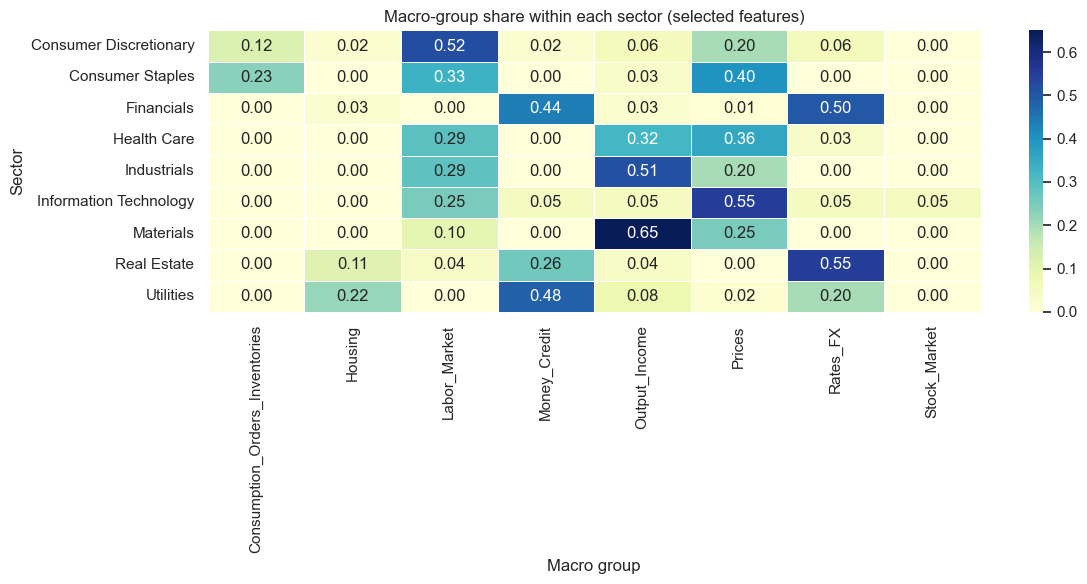

In [8]:
heatmap_df = sector_group_share.pivot(index='sector', columns='macro_group', values='share_within_sector').fillna(0.0)
heatmap_df = heatmap_df.sort_index()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Macro-group share within each sector (selected features)')
plt.xlabel('Macro group')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()


In [9]:
# Top macro feature per sector by average composite score
sector_top_features = (
    sector_selected.groupby(['sector', 'macro_feature', 'macro_group'], as_index=False)['composite_score']
    .mean()
    .sort_values(['sector', 'composite_score'], ascending=[True, False])
    .groupby('sector')
    .head(5)
)

display(sector_top_features)


,sector,macro_feature,macro_group,composite_score
26,Consumer Discretionary,RSAFS,Consumption_Orders_Inventories,1.000000
4,Consumer Discretionary,CMRMTSPL,Consumption_Orders_Inventories,0.972123
9,Consumer Discretionary,DPCERA3M086SBEA,Consumption_Orders_Inventories,0.970165
3,Consumer Discretionary,CLF16OV,Labor_Market,0.940865
27,Consumer Discretionary,SRVPRD,Labor_Market,0.927141
46,Consumer Staples,DNDGRG3M086SBEA,Prices,0.970827
37,Consumer Staples,ANDENO,Consumption_Orders_Inventories,0.955718
43,Consumer Staples,CUSR0000SAC,Prices,0.891627
42,Consumer Staples,CPITRNSL,Prices,0.863090
50,Consumer Staples,MCOILWTICO,Prices,0.829966
